**Media SARIMAX at 1, 3 and 6 month lags**

In [158]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

In [159]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def Evaluator(actual, prediction):
    # Convert to Series so we can align/drop NaNs
    actual = pd.Series(actual).reset_index(drop=True)
    prediction = pd.Series(prediction).reset_index(drop=True)

    # Combine into one dataframe
    results = pd.DataFrame({
        "actual": actual,
        "prediction": prediction
    })

    # Remove NaN rows
    results = results.dropna()

    # Calculate metrics
    mae = mean_absolute_error(
        results["actual"],
        results["prediction"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            results["actual"],
            results["prediction"]
        )
    )

    r2 = r2_score(
        results["actual"],
        results["prediction"]
    )

    print(f"Observations used: {len(results)}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

def abline(slope, intercept, color):
    color='maroon'
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', color=color)

In [160]:
California=pd.read_csv('../data/interim/Media_with_features.csv')
California.tail()

,year_month,article_count,rate_per_100k,mean_title_sentiment,mean_title_risk,mean_body_risk,avg_sentiment,avg_risk,mean_body_sentiment,tweet_count,avg_likes
162,2024-08,13.0,2.732767,-0.326091,0.096703,0.045826,-0.257489,0.008000,-0.281135,5,5.200000
163,2024-09,8.0,2.888596,-0.303249,0.166465,0.051671,-0.389060,0.046625,-0.357077,79,9.088608
164,2024-10,2.0,3.471509,-0.038529,0.000000,0.005682,-0.214284,0.019336,-0.169596,33,13.909091
165,2024-11,1.0,3.584052,-0.047367,0.000000,0.008351,-0.195193,0.011013,-0.433891,14,10.857143
166,2024-12,2.0,3.627337,0.062540,0.200000,0.040054,-0.375388,0.006341,-0.469066,25,43.200000


In [161]:
def adf_test(series, name):

    result = adfuller(series)

    print("="*60)
    print(name)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"P-value       : {result[1]:.4f}")

    if result[1] < 0.05:    
        print("Stationary")
    else:
        print("Non-stationary")

cols =['article_count', 'rate_per_100k', 'mean_title_sentiment',
       'mean_title_risk', 'mean_body_risk', 'avg_sentiment', 'avg_risk',
       'mean_body_sentiment', 'tweet_count', 'avg_likes']

for col in cols:
    adf_test(California[col], col)

adf_test(California['rate_per_100k'], "VF Rate per 100k")

article_count
ADF Statistic : -7.0902
P-value       : 0.0000
Stationary
rate_per_100k
ADF Statistic : -0.2003
P-value       : 0.9385
Non-stationary
mean_title_sentiment
ADF Statistic : -11.0878
P-value       : 0.0000
Stationary
mean_title_risk
ADF Statistic : -12.3249
P-value       : 0.0000
Stationary
mean_body_risk
ADF Statistic : -10.8205
P-value       : 0.0000
Stationary
avg_sentiment
ADF Statistic : -4.3870
P-value       : 0.0003
Stationary
avg_risk
ADF Statistic : -3.4830
P-value       : 0.0084
Stationary
mean_body_sentiment
ADF Statistic : -13.7563
P-value       : 0.0000
Stationary
tweet_count
ADF Statistic : -2.3188
P-value       : 0.1660
Non-stationary
avg_likes
ADF Statistic : -2.4387
P-value       : 0.1311
Non-stationary
VF Rate per 100k
ADF Statistic : -0.2003
P-value       : 0.9385
Non-stationary


In [162]:
California['log_rate'] = np.log1p(
    California['rate_per_100k']
)
adf_test(California['log_rate'], "VF Rate per 100k")

California['logdiff_rate']= California['log_rate'].diff()
California= California.dropna(subset= 'logdiff_rate')
adf_test(California['logdiff_rate'], 'VF logdiffed rates')

VF Rate per 100k
ADF Statistic : -0.3003
P-value       : 0.9255
Non-stationary
VF logdiffed rates
ADF Statistic : -8.1790
P-value       : 0.0000
Stationary


In [163]:
#total is 166 months
onem= 165
threem= 163
sixm= 160

In [164]:
train1 = California.iloc[:onem]
test1 = California.iloc[onem:]

train3 = California.iloc[:threem]
test3 = California.iloc[threem:]

train6 = California.iloc[:sixm]
test6 = California.iloc[sixm:]

In [165]:
# test1= test1.drop(columns= ['logdiff_rate', 'log_rate','rate_per_100k'])
# test3= test3.drop(columns=['logdiff_rate', 'log_rate','rate_per_100k'])
# test6= test6.drop(columns=['logdiff_rate', 'log_rate','rate_per_100k'])

In [166]:
test1.head()

,year_month,article_count,rate_per_100k,mean_title_sentiment,mean_title_risk,mean_body_risk,avg_sentiment,avg_risk,mean_body_sentiment,tweet_count,avg_likes,log_rate,logdiff_rate
166,2024-12,2.0,3.627337,0.06254,0.2,0.040054,-0.375388,0.006341,-0.469066,25,43.2,1.531982,0.009398


In [184]:
testcols= ['article_count','mean_title_sentiment','mean_title_risk','mean_body_risk','avg_sentiment','avg_risk','mean_body_sentiment', 'tweet_count','avg_likes']
artcols= ['article_count','mean_title_sentiment','mean_title_risk','mean_body_risk']
twcols= ['avg_sentiment','avg_risk','mean_body_sentiment','tweet_count','avg_likes']

In [185]:
# 1-month: train on first 155, test on last 1
One_month_Media = SARIMAX(
    endog=train1['logdiff_rate'],
    exog=train1[testcols],
    order=(12,0,0)
).fit()

# Forecast 1 step ahead
forecast = One_month_Media.get_forecast(steps=1, exog=test1[testcols])
forecast_values = forecast.predicted_mean

In [186]:
print(One_month_Media.summary())

                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  165
Model:              SARIMAX(12, 0, 0)   Log Likelihood                 179.950
Date:                Mon, 28 Sep 2026   AIC                           -315.900
Time:                        16:13:12   BIC                           -247.570
Sample:                             0   HQIC                          -288.163
                                - 165                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0016      0.003      0.561      0.574      -0.004       0.007
mean_title_sentiment     0.0175      0.030      0.586      0.558      -0.041       0.076
mean_title_r

In [187]:
forecast_values

166    0.068013
dtype: float64

In [200]:
test1['logdiff_rate'].iloc[0] - forecast.predicted_mean.iloc[0]

np.float64(-0.05861418856370637)

In [190]:
def sarimax_evaluation(train, test, endog, exog, order):
    model = SARIMAX(
        endog=train[endog],
        exog=train[exog],
        order=order
    ).fit()

    forecast = model.get_forecast(steps=len(test), exog=test[exog])
    forecast_values = forecast.predicted_mean

    Evaluator(test[endog], forecast_values)
    return print(model.summary())

In [206]:
sarimax_evaluation(train1, test1, 'logdiff_rate',testcols, (1,0,0))

Observations used: 1
MAE: 0.0244
RMSE: 0.0244
R²: nan
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  165
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 154.140
Date:                Mon, 28 Sep 2026   AIC                           -286.280
Time:                        16:16:42   BIC                           -252.115
Sample:                             0   HQIC                          -272.411
                                - 165                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0044      0.004      1.039      0.299      -0.004       0.013
mean_title_sentiment     0.0059      0.031     

c:\Users\zions\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [205]:
sarimax_evaluation(train3, test3, 'logdiff_rate', testcols, (3,0,0))

Observations used: 3
MAE: 0.0641
RMSE: 0.0819
R²: -0.9839
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  163
Model:               SARIMAX(3, 0, 0)   Log Likelihood                 157.048
Date:                Mon, 28 Sep 2026   AIC                           -288.095
Time:                        16:16:33   BIC                           -247.876
Sample:                             0   HQIC                          -271.767
                                - 163                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0046      0.004      1.247      0.212      -0.003       0.012
mean_title_sentiment     0.0059      0.029 

c:\Users\zions\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [204]:
sarimax_evaluation(train6, test6, 'logdiff_rate',testcols, (6,0,0))

Observations used: 6
MAE: 0.0503
RMSE: 0.0609
R²: -1.1018
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  160
Model:               SARIMAX(6, 0, 0)   Log Likelihood                 162.512
Date:                Mon, 28 Sep 2026   AIC                           -293.024
Time:                        16:16:25   BIC                           -243.822
Sample:                             0   HQIC                          -273.045
                                - 160                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0031      0.003      0.905      0.366      -0.004       0.010
mean_title_sentiment     0.0156      0.031 

In [203]:
sarimax_evaluation(train1, test1, 'logdiff_rate', artcols, (1,0,0))

Observations used: 1
MAE: 0.0092
RMSE: 0.0092
R²: nan
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  165
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 154.187
Date:                Mon, 28 Sep 2026   AIC                           -296.374
Time:                        16:16:17   BIC                           -277.738
Sample:                             0   HQIC                          -288.809
                                - 165                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0046      0.003      1.399      0.162      -0.002       0.011
mean_title_sentiment    -0.0004      0.030     

c:\Users\zions\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [202]:
sarimax_evaluation(train3, test3, 'logdiff_rate', artcols, (3,0,0))

Observations used: 3
MAE: 0.0601
RMSE: 0.0814
R²: -0.9633
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  163
Model:               SARIMAX(3, 0, 0)   Log Likelihood                 156.806
Date:                Mon, 28 Sep 2026   AIC                           -297.611
Time:                        16:16:02   BIC                           -272.861
Sample:                             0   HQIC                          -287.563
                                - 163                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0041      0.003      1.282      0.200      -0.002       0.010
mean_title_sentiment     0.0020      0.027 

c:\Users\zions\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [216]:
sarimax_evaluation(train6, test6, 'logdiff_rate', artcols, (12,0,0))

Observations used: 6
MAE: 0.0428
RMSE: 0.0453
R²: -0.1630
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  160
Model:              SARIMAX(12, 0, 0)   Log Likelihood                 172.500
Date:                Mon, 28 Sep 2026   AIC                           -311.000
Time:                        16:36:57   BIC                           -258.722
Sample:                             0   HQIC                          -289.771
                                - 160                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
article_count            0.0043      0.002      1.965      0.049    1.06e-05       0.009
mean_title_sentiment     0.0135      0.025 

In [217]:
forecast_values

166    0.068013
dtype: float64

In [218]:
print(len(California))   # total rows
print(len(test6))        # should be 6


166
6


KeyError: "None of [Index([0.06801254681998214], dtype='float64')] are in the [columns]"

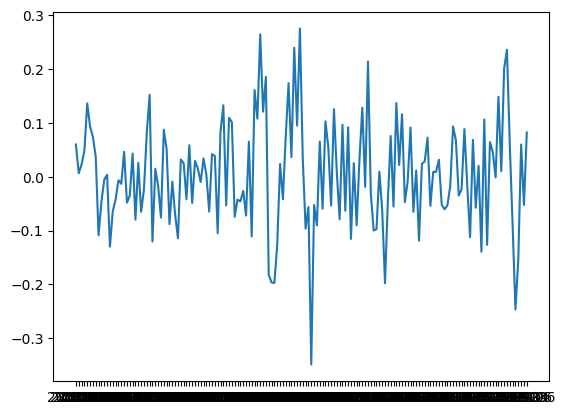

In [214]:
plt.plot(
    train6['year_month'],
    train6['logdiff_rate']
)

plt.plot(
    test6['year_month'],
    test6[forecast_values]
)

In [207]:
sarimax_evaluation(train1, test1, 'logdiff_rate', twcols, (1,0,0))

Observations used: 1
MAE: 0.0176
RMSE: 0.0176
R²: nan
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  165
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 153.425
Date:                Mon, 28 Sep 2026   AIC                           -292.850
Time:                        16:17:27   BIC                           -271.108
Sample:                             0   HQIC                          -284.024
                                - 165                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
avg_sentiment          -0.0139      0.064     -0.218      0.827      -0.139       0.111
avg_risk               -0.0408      0.490     -0.0

c:\Users\zions\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [208]:
sarimax_evaluation(train3, test3, 'logdiff_rate', twcols, (3,0,0))

Observations used: 3
MAE: 0.0512
RMSE: 0.0722
R²: -0.5455
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  163
Model:               SARIMAX(3, 0, 0)   Log Likelihood                 155.730
Date:                Mon, 28 Sep 2026   AIC                           -293.460
Time:                        16:17:33   BIC                           -265.616
Sample:                             0   HQIC                          -282.156
                                - 163                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
avg_sentiment          -0.0125      0.060     -0.207      0.836      -0.131       0.106
avg_risk               -0.0381      0.447     

In [209]:
sarimax_evaluation(train6, test6, 'logdiff_rate', twcols, (6,0,0))

Observations used: 6
MAE: 0.0445
RMSE: 0.0549
R²: -0.7112
                               SARIMAX Results                                
Dep. Variable:           logdiff_rate   No. Observations:                  160
Model:               SARIMAX(6, 0, 0)   Log Likelihood                 162.012
Date:                Mon, 28 Sep 2026   AIC                           -300.024
Time:                        16:17:41   BIC                           -263.122
Sample:                             0   HQIC                          -285.040
                                - 160                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
avg_sentiment          -0.0095      0.049     -0.196      0.845      -0.105       0.086
avg_risk               -0.0552      0.356     